In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [14]:
# Cell 1 — Setup & Imports
!pip install gymnasium matplotlib numpy torch imageio pillow -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation
from IPython.display import display, HTML, clear_output
import torch
import torch.nn as nn
import torch.optim as optim
import random
import collections
import imageio
from PIL import Image
import io
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'} (CPU is fine for Q-Learning!)")

✅ All imports successful!
PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda (CPU is fine for Q-Learning!)


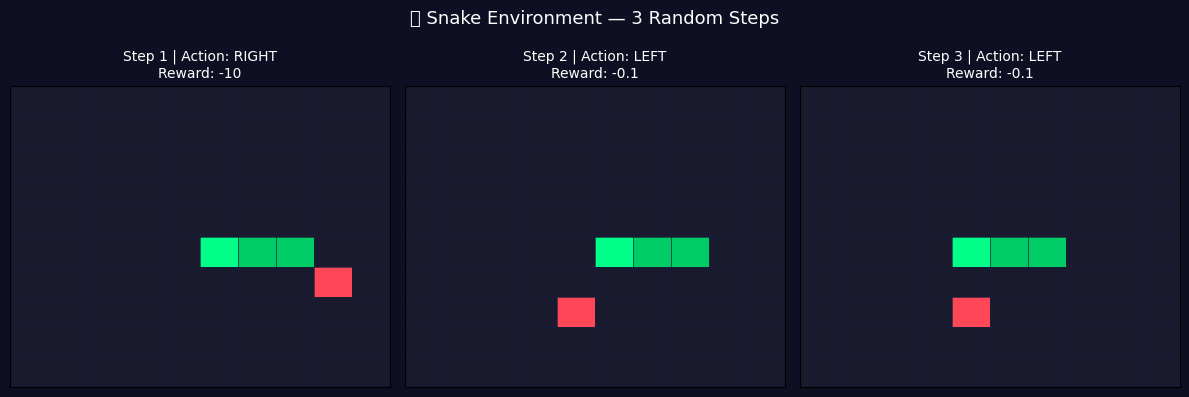


✅ Environment working!
State space size : 11 features
Action space size: 4 (UP, DOWN, LEFT, RIGHT)
Sample state     : [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.]


In [13]:
# Cell 2 — Custom Snake Environment

class SnakeEnv:
    def __init__(self, grid_size=10):
        self.grid_size = grid_size
        self.reset()

    # Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    ACTIONS = [(-1,0), (1,0), (0,-1), (0,1)]
    ACTION_NAMES = ['UP', 'DOWN', 'LEFT', 'RIGHT']

    def reset(self):
        mid = self.grid_size // 2
        self.snake = [(mid, mid), (mid, mid+1), (mid, mid+2)]  # head first
        self.direction = 0  # start moving UP
        self.place_food()
        self.steps = 0
        self.max_steps = self.grid_size * self.grid_size * 2
        return self.get_state()

    def place_food(self):
        empty = [(r,c) for r in range(self.grid_size)
                       for c in range(self.grid_size)
                       if (r,c) not in self.snake]
        self.food = random.choice(empty) if empty else (-1,-1)

    def get_state(self):
        head = self.snake[0]
        # 11 binary features (classic Snake RL state)
        dr, dc = self.ACTIONS[self.direction]

        def is_danger(r, c):
            return (r < 0 or r >= self.grid_size or
                    c < 0 or c >= self.grid_size or
                    (r, c) in self.snake)

        # Danger straight, right, left
        danger_straight = int(is_danger(head[0]+dr, head[1]+dc))
        danger_right    = int(is_danger(head[0]+dc, head[1]-dr))
        danger_left     = int(is_danger(head[0]-dc, head[1]+dr))

        # Current direction (one-hot)
        dir_up    = int(self.direction == 0)
        dir_down  = int(self.direction == 1)
        dir_left  = int(self.direction == 2)
        dir_right = int(self.direction == 3)

        # Food direction relative to head
        food_up    = int(self.food[0] < head[0])
        food_down  = int(self.food[0] > head[0])
        food_left  = int(self.food[1] < head[1])
        food_right = int(self.food[1] > head[1])

        return np.array([
            danger_straight, danger_right, danger_left,
            dir_up, dir_down, dir_left, dir_right,
            food_up, food_down, food_left, food_right
        ], dtype=np.float32)

    def step(self, action):
        # Prevent reversing direction
        opposites = {0:1, 1:0, 2:3, 3:2}
        if action != opposites[self.direction]:
            self.direction = action

        dr, dc = self.ACTIONS[self.direction]
        head = self.snake[0]
        new_head = (head[0] + dr, head[1] + dc)

        # Check collision
        if (new_head[0] < 0 or new_head[0] >= self.grid_size or
            new_head[1] < 0 or new_head[1] >= self.grid_size or
            new_head in self.snake):
            return self.get_state(), -10, True  # reward, done

        self.snake.insert(0, new_head)

        # Check food
        if new_head == self.food:
            reward = 10
            self.place_food()
        else:
            self.snake.pop()  # move forward
            reward = -0.1     # small penalty to encourage efficiency

        self.steps += 1
        done = self.steps >= self.max_steps

        return self.get_state(), reward, done

    def render(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(4,4))
        ax.clear()
        ax.set_xlim(0, self.grid_size)
        ax.set_ylim(0, self.grid_size)
        ax.set_facecolor('#1a1a2e')
        ax.set_xticks([]); ax.set_yticks([])

        # Draw grid lines subtly
        for i in range(self.grid_size+1):
            ax.axhline(i, color='#16213e', lw=0.5)
            ax.axvline(i, color='#16213e', lw=0.5)

        # Draw snake body
        for i, (r, c) in enumerate(self.snake):
            color = '#00ff88' if i == 0 else '#00cc66'  # head brighter
            rect = patches.Rectangle((c, self.grid_size-1-r), 1, 1,
                                       linewidth=0, facecolor=color)
            ax.add_patch(rect)

        # Draw food
        fr, fc = self.food
        food_rect = patches.Rectangle((fc, self.grid_size-1-fr), 1, 1,
                                        linewidth=0, facecolor='#ff4757')
        ax.add_patch(food_rect)
        return ax


# ── Quick sanity check ──
env = SnakeEnv(grid_size=10)
state = env.reset()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor('#0f0f23')

for i, ax in enumerate(axes):
    env.render(ax)
    action = random.randint(0, 3)
    state, reward, done = env.step(action)
    ax.set_title(f"Step {i+1} | Action: {env.ACTION_NAMES[action]}\nReward: {reward}",
                 color='white', fontsize=10)
    if done:
        env.reset()

plt.suptitle("🐍 Snake Environment — 3 Random Steps", color='white', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n✅ Environment working!")
print(f"State space size : {state.shape[0]} features")
print(f"Action space size: 4 (UP, DOWN, LEFT, RIGHT)")
print(f"Sample state     : {state}")

In [12]:
# Cell 3 — Q-Learning Agent + Training

class QLearningAgent:
    def __init__(self, state_size=11, action_size=4):
        self.state_size  = state_size
        self.action_size = action_size

        # Hyperparameters
        self.alpha   = 0.1    # learning rate
        self.gamma   = 0.9    # discount factor
        self.epsilon = 1.0    # exploration rate (starts fully random)
        self.eps_min = 0.01
        self.eps_decay = 0.995

        # Q-table: state is 11 binary features → discretize to string key
        self.q_table = {}

    def state_to_key(self, state):
        return tuple(state.astype(int))

    def get_q(self, state):
        key = self.state_to_key(state)
        if key not in self.q_table:
            self.q_table[key] = np.zeros(self.action_size)
        return self.q_table[key]

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)  # explore
        return np.argmax(self.get_q(state))                 # exploit

    def learn(self, state, action, reward, next_state, done):
        q_vals      = self.get_q(state)
        next_q_vals = self.get_q(next_state)

        # Q-Learning update rule
        target = reward + (0 if done else self.gamma * np.max(next_q_vals))
        q_vals[action] += self.alpha * (target - q_vals[action])

        # Decay epsilon
        if done:
            self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)


# ── Training Loop ──
env   = SnakeEnv(grid_size=10)
agent = QLearningAgent()

N_EPISODES   = 2000
PLOT_EVERY   = 200   # print progress every N episodes

rewards_history = []
scores_history  = []   # snake length - 3 (foods eaten)
eps_history     = []

print("🚀 Starting Q-Learning Training...")
print(f"{'Episode':>8} | {'Avg Reward':>10} | {'Avg Score':>10} | {'Epsilon':>8} | {'Q-States':>9}")
print("-" * 58)

for ep in range(1, N_EPISODES + 1):
    state      = env.reset()
    total_reward = 0
    done       = False

    while not done:
        action               = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state, done)
        state        = next_state
        total_reward += reward

    rewards_history.append(total_reward)
    scores_history.append(len(env.snake) - 3)
    eps_history.append(agent.epsilon)

    if ep % PLOT_EVERY == 0:
        avg_r = np.mean(rewards_history[-PLOT_EVERY:])
        avg_s = np.mean(scores_history[-PLOT_EVERY:])
        print(f"{ep:>8} | {avg_r:>10.2f} | {avg_s:>10.2f} | {agent.epsilon:>8.4f} | {len(agent.q_table):>9}")

print("\n✅ Training complete!")
print(f"Total unique Q-states discovered: {len(agent.q_table)}")
print(f"Final epsilon (exploration rate): {agent.epsilon:.4f}")
print(f"Best score achieved             : {max(scores_history)} foods eaten")

🚀 Starting Q-Learning Training...
 Episode | Avg Reward |  Avg Score |  Epsilon |  Q-States
----------------------------------------------------------
     200 |      -5.34 |       0.61 |   0.3670 |       171
     400 |      18.21 |       3.11 |   0.1347 |       215
     600 |      52.00 |       6.71 |   0.0494 |       241
     800 |      93.55 |      11.18 |   0.0181 |       250
    1000 |     124.36 |      14.38 |   0.0100 |       253
    1200 |     124.52 |      14.43 |   0.0100 |       255
    1400 |     129.56 |      14.93 |   0.0100 |       255
    1600 |     126.10 |      14.57 |   0.0100 |       255
    1800 |     135.02 |      15.53 |   0.0100 |       255
    2000 |     129.15 |      14.88 |   0.0100 |       256

✅ Training complete!
Total unique Q-states discovered: 256
Final epsilon (exploration rate): 0.0100
Best score achieved             : 27 foods eaten


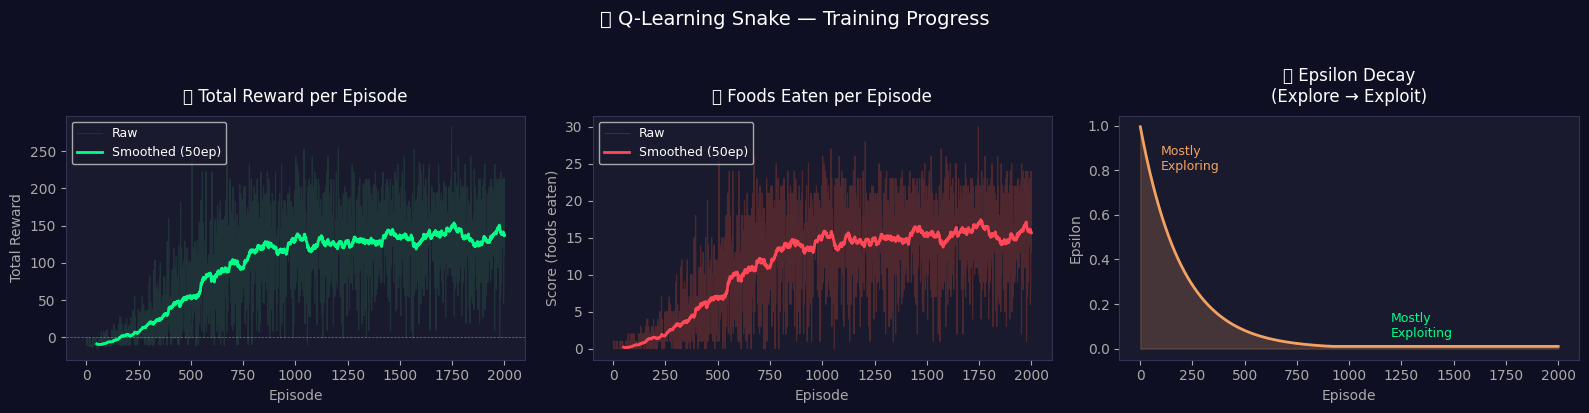

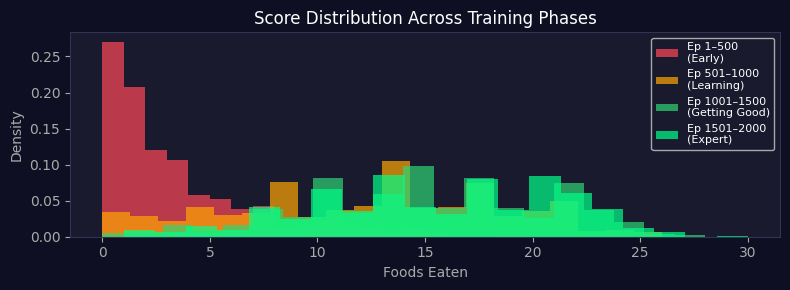

In [11]:
# Cell 4 — Training Visualization (Learning Curves)

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0f0f23')

episodes = np.arange(1, N_EPISODES + 1)

# ── Plot 1: Reward Curve ──
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ax1.plot(episodes, rewards_history, color='#2d6a4f', alpha=0.3, lw=0.8, label='Raw')
ax1.plot(episodes[49:], smooth(rewards_history), color='#00ff88', lw=2, label='Smoothed (50ep)')
ax1.axhline(0, color='white', lw=0.5, linestyle='--', alpha=0.4)
ax1.set_title('📈 Total Reward per Episode', color='white', fontsize=12, pad=10)
ax1.set_xlabel('Episode', color='#aaaaaa')
ax1.set_ylabel('Total Reward', color='#aaaaaa')
ax1.tick_params(colors='#aaaaaa')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for spine in ax1.spines.values(): spine.set_edgecolor('#333355')

# ── Plot 2: Score Curve (foods eaten) ──
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.plot(episodes, scores_history, color='#c84b31', alpha=0.3, lw=0.8, label='Raw')
ax2.plot(episodes[49:], smooth(scores_history), color='#ff4757', lw=2, label='Smoothed (50ep)')
ax2.set_title('🍎 Foods Eaten per Episode', color='white', fontsize=12, pad=10)
ax2.set_xlabel('Episode', color='#aaaaaa')
ax2.set_ylabel('Score (foods eaten)', color='#aaaaaa')
ax2.tick_params(colors='#aaaaaa')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for spine in ax2.spines.values(): spine.set_edgecolor('#333355')

# ── Plot 3: Epsilon Decay ──
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
ax3.plot(episodes, eps_history, color='#f4a261', lw=2)
ax3.fill_between(episodes, eps_history, alpha=0.2, color='#f4a261')
ax3.set_title('🎲 Epsilon Decay\n(Explore → Exploit)', color='white', fontsize=12, pad=10)
ax3.set_xlabel('Episode', color='#aaaaaa')
ax3.set_ylabel('Epsilon', color='#aaaaaa')
ax3.tick_params(colors='#aaaaaa')

# Annotate phases
ax3.annotate('Mostly\nExploring', xy=(100, 0.8), color='#f4a261', fontsize=9)
ax3.annotate('Mostly\nExploiting', xy=(1200, 0.05), color='#00ff88', fontsize=9)
for spine in ax3.spines.values(): spine.set_edgecolor('#333355')

plt.suptitle('🐍 Q-Learning Snake — Training Progress', color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f23')
plt.show()

# ── Score Distribution ──
fig2, ax = plt.subplots(figsize=(8, 3))
fig2.patch.set_facecolor('#0f0f23')
ax.set_facecolor('#1a1a2e')

# Split into quarters to show improvement
quarter = N_EPISODES // 4
colors  = ['#ff4757', '#ffa502', '#2ed573', '#00ff88']
labels  = ['Ep 1–500\n(Early)', 'Ep 501–1000\n(Learning)',
           'Ep 1001–1500\n(Getting Good)', 'Ep 1501–2000\n(Expert)']

for i, (c, l) in enumerate(zip(colors, labels)):
    chunk = scores_history[i*quarter:(i+1)*quarter]
    ax.hist(chunk, bins=20, alpha=0.7, color=c, label=l, density=True)

ax.set_title('Score Distribution Across Training Phases', color='white', fontsize=12)
ax.set_xlabel('Foods Eaten', color='#aaaaaa')
ax.set_ylabel('Density', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0f23')
plt.show()



 Recording episodes at different skill levels...

1️  Random Agent (no learning, ε=1.0)
  Saved → random_agent.gif (33 frames)
     Score: 1 foods | Reward: -3.1

2️  Trained Agent (fully trained, ε=0.0)
  Saved → trained_agent.gif (172 frames)
     Score: 15 foods | Reward: 124.4

Rendering side-by-side snapshot comparison...


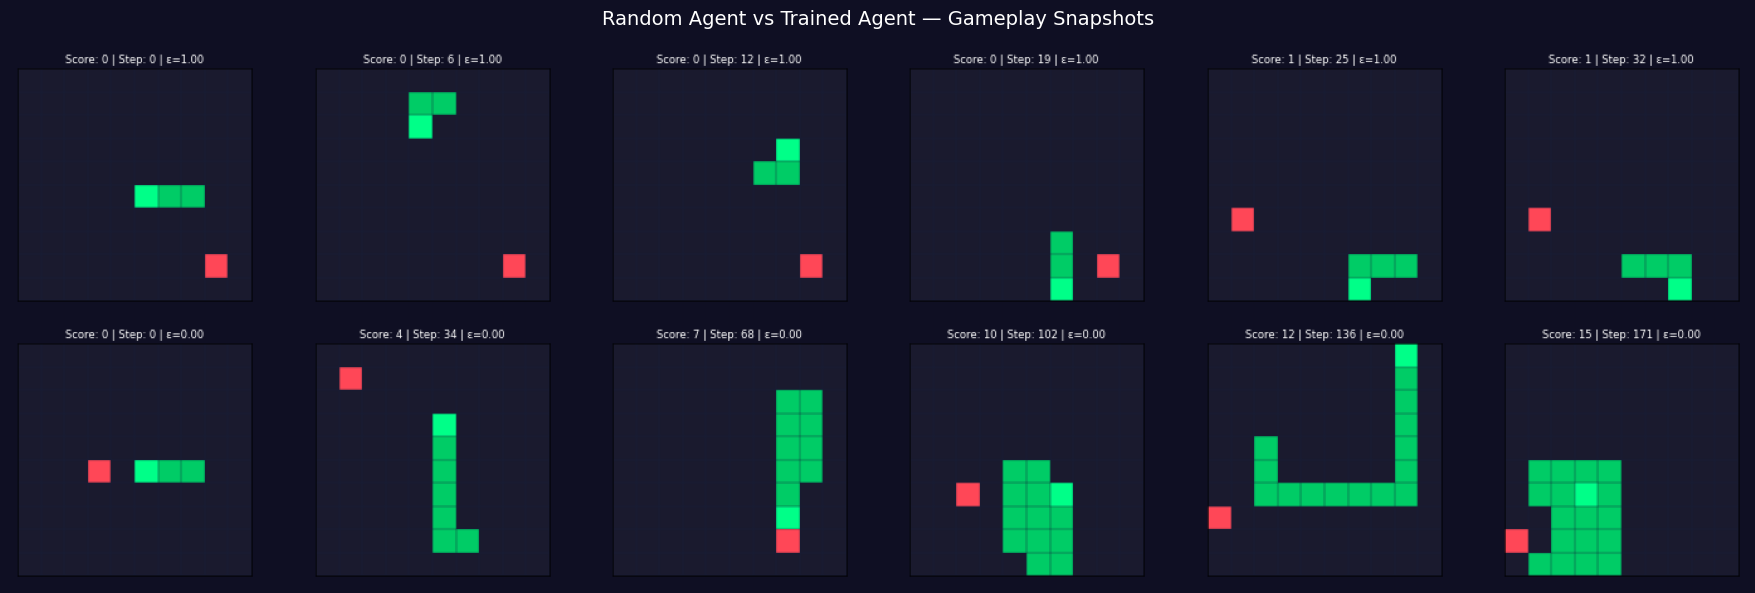


 Done! Files saved:
    random_agent.gif  — agent with no learning
    trained_agent.gif — agent after 2000 episodes
    comparison.png    — side by side snapshots

 Random Agent Score : 1
 Trained Agent Score: 15


In [10]:
# Cell 5 — Render Gameplay GIF (Early vs Trained Agent)

def record_episode(env, agent, epsilon_override=0.0, max_steps=200):
    """Record frames of one episode"""
    agent.epsilon = epsilon_override
    state = env.reset()
    frames = []
    total_reward = 0
    done = False
    step = 0

    while not done and step < max_steps:
        fig, ax = plt.subplots(figsize=(4, 4))
        fig.patch.set_facecolor('#0f0f23')
        env.render(ax)
        score = len(env.snake) - 3
        ax.set_title(f"Score: {score} | Step: {step} | ε={epsilon_override:.2f}",
                     color='white', fontsize=10)

        # Capture frame
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=60,
                    bbox_inches='tight', facecolor='#0f0f23')
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        plt.close()

        action = agent.choose_action(state)
        state, reward, done = env.step(action)
        total_reward += reward
        step += 1

    return frames, total_reward, len(env.snake) - 3


def frames_to_gif(frames, path, fps=8):
    imageio.mimsave(path, [np.array(f) for f in frames], fps=fps)
    print(f"  Saved → {path} ({len(frames)} frames)")


env_vis = SnakeEnv(grid_size=10)

print(" Recording episodes at different skill levels...\n")

# ── Random agent (epsilon=1.0) ──
print("1️  Random Agent (no learning, ε=1.0)")
frames_random, r1, s1 = record_episode(env_vis, agent, epsilon_override=1.0)
frames_to_gif(frames_random, 'random_agent.gif', fps=6)
print(f"     Score: {s1} foods | Reward: {r1:.1f}\n")

# ── Trained agent (epsilon=0.0, pure exploit) ──
print("2️  Trained Agent (fully trained, ε=0.0)")
frames_trained, r2, s2 = record_episode(env_vis, agent, epsilon_override=0.0)
frames_to_gif(frames_trained, 'trained_agent.gif', fps=8)
print(f"     Score: {s2} foods | Reward: {r2:.1f}\n")

# ── Show side-by-side snapshots (every Nth frame) ──
print("Rendering side-by-side snapshot comparison...")

N = 6  # pick 6 frames from each
def sample_frames(frames, n=6):
    idxs = np.linspace(0, len(frames)-1, n, dtype=int)
    return [frames[i] for i in idxs]

rand_sample    = sample_frames(frames_random)
trained_sample = sample_frames(frames_trained)

fig, axes = plt.subplots(2, N, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f23')

for i in range(N):
    for j, (frames_row, label, color) in enumerate([
        (rand_sample,    ' RANDOM',  '#ff4757'),
        (trained_sample, ' TRAINED', '#00ff88')
    ]):
        axes[j][i].imshow(frames_row[i])
        axes[j][i].axis('off')
        if i == 0:
            axes[j][i].set_ylabel(label, color=color,
                                  fontsize=12, fontweight='bold',
                                  rotation=0, labelpad=60, va='center')

plt.suptitle('Random Agent vs Trained Agent — Gameplay Snapshots',
             color='white', fontsize=14)
plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight', facecolor='#0f0f23')
plt.show()

print("\n Done! Files saved:")
print("    random_agent.gif  — agent with no learning")
print("    trained_agent.gif — agent after 2000 episodes")
print("    comparison.png    — side by side snapshots")
print(f"\n Random Agent Score : {s1}")
print(f" Trained Agent Score: {s2}")

In [9]:
# Cell 6 — Deep Q-Network (DQN) Agent

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Neural Network ──
class DQN(nn.Module):
    def __init__(self, state_size=11, action_size=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.net(x)


# ── Replay Buffer ──
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (torch.FloatTensor(np.array(s)).to(DEVICE),
                torch.LongTensor(a).to(DEVICE),
                torch.FloatTensor(r).to(DEVICE),
                torch.FloatTensor(np.array(ns)).to(DEVICE),
                torch.FloatTensor(d).to(DEVICE))

    def __len__(self):
        return len(self.buffer)


# ── DQN Agent ──
class DQNAgent:
    def __init__(self, state_size=11, action_size=4):
        self.action_size = action_size
        self.epsilon     = 1.0
        self.eps_min     = 0.01
        self.eps_decay   = 0.997
        self.gamma       = 0.95
        self.lr          = 1e-3
        self.batch_size  = 128

        self.policy_net  = DQN(state_size, action_size).to(DEVICE)
        self.target_net  = DQN(state_size, action_size).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer   = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.memory      = ReplayBuffer()
        self.update_every = 10   # sync target net every N episodes
        self.ep_count     = 0

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            return self.policy_net(s).argmax().item()

    def learn(self):
        if len(self.memory) < self.batch_size:
            return None

        s, a, r, ns, d = self.memory.sample(self.batch_size)

        # Current Q values
        q_vals = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze()

        # Target Q values (Bellman)
        with torch.no_grad():
            next_q = self.target_net(ns).max(1)[0]
            targets = r + self.gamma * next_q * (1 - d)

        loss = nn.MSELoss()(q_vals, targets)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        return loss.item()

    def end_episode(self):
        self.epsilon  = max(self.eps_min, self.epsilon * self.eps_decay)
        self.ep_count += 1
        if self.ep_count % self.update_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())


# ── DQN Training ──
env_dqn   = SnakeEnv(grid_size=10)
dqn_agent = DQNAgent()

DQN_EPISODES  = 1500
PLOT_EVERY    = 150

dqn_rewards  = []
dqn_scores   = []
dqn_losses   = []
dqn_eps      = []

print(f"Training DQN on {DEVICE}...")
print(f"{'Episode':>8} | {'Avg Reward':>10} | {'Avg Score':>10} | {'Avg Loss':>10} | {'Epsilon':>8}")
print("-" * 62)

for ep in range(1, DQN_EPISODES + 1):
    state        = env_dqn.reset()
    total_reward = 0
    ep_losses    = []
    done         = False

    while not done:
        action = dqn_agent.choose_action(state)
        next_state, reward, done = env_dqn.step(action)
        dqn_agent.memory.push(state, action, reward, next_state, float(done))

        loss = dqn_agent.learn()
        if loss: ep_losses.append(loss)

        state        = next_state
        total_reward += reward

    dqn_agent.end_episode()
    dqn_rewards.append(total_reward)
    dqn_scores.append(len(env_dqn.snake) - 3)
    dqn_losses.append(np.mean(ep_losses) if ep_losses else 0)
    dqn_eps.append(dqn_agent.epsilon)

    if ep % PLOT_EVERY == 0:
        avg_r = np.mean(dqn_rewards[-PLOT_EVERY:])
        avg_s = np.mean(dqn_scores[-PLOT_EVERY:])
        avg_l = np.mean(dqn_losses[-PLOT_EVERY:])
        print(f"{ep:>8} | {avg_r:>10.2f} | {avg_s:>10.2f} | {avg_l:>10.4f} | {dqn_agent.epsilon:>8.4f}")

print("\n DQN Training complete!")
print(f"Best score achieved: {max(dqn_scores)} foods eaten")
print(f"Final epsilon      : {dqn_agent.epsilon:.4f}")

Training DQN on cuda...
 Episode | Avg Reward |  Avg Score |   Avg Loss |  Epsilon
--------------------------------------------------------------
     150 |      -7.47 |       0.40 |     1.8517 |   0.6372
     300 |       4.09 |       1.61 |     2.6745 |   0.4060
     450 |      16.25 |       2.89 |     3.6059 |   0.2587
     600 |      30.71 |       4.44 |     4.6951 |   0.1649
     750 |      49.38 |       6.39 |     5.3393 |   0.1050
     900 |      66.37 |       8.22 |     6.0401 |   0.0669
    1050 |      97.20 |      11.50 |     7.1840 |   0.0426
    1200 |     110.53 |      12.89 |     8.4634 |   0.0272
    1350 |     129.24 |      14.87 |     9.6079 |   0.0173
    1500 |     130.12 |      14.92 |    10.2990 |   0.0110

 DQN Training complete!
Best score achieved: 30 foods eaten
Final epsilon      : 0.0110


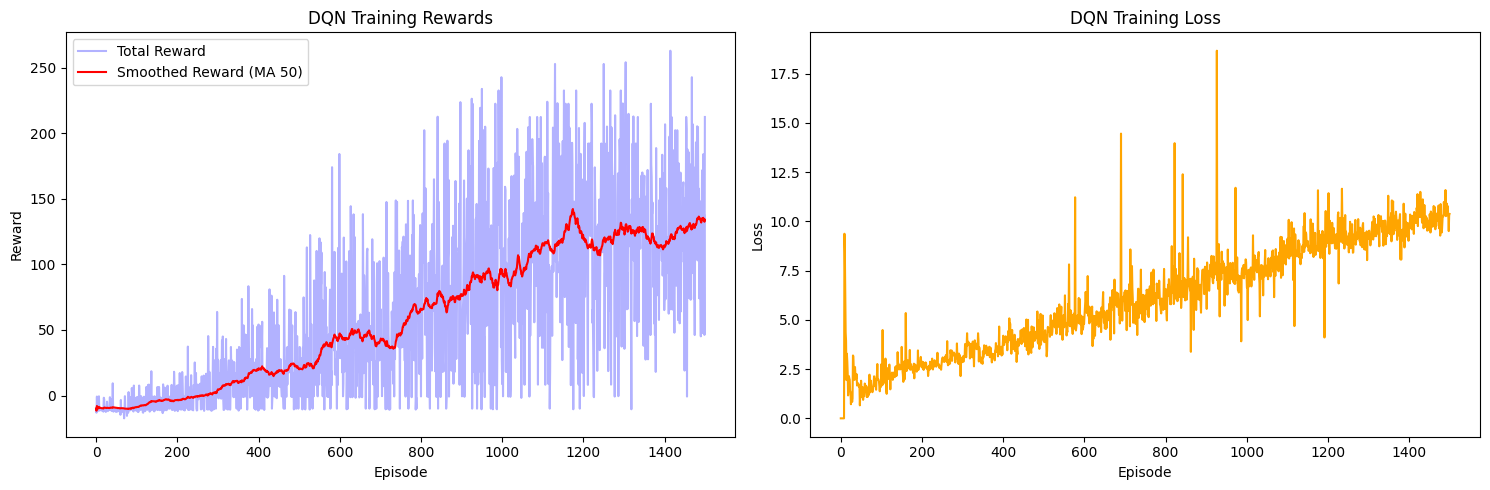

In [8]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Rewards
ax1.plot(dqn_rewards, label='Total Reward', color='blue', alpha=0.3)
# Calculate a moving average to smooth the line
smooth_rewards = [np.mean(dqn_rewards[max(0, i-50):i+1]) for i in range(len(dqn_rewards))]
ax1.plot(smooth_rewards, label='Smoothed Reward (MA 50)', color='red')
ax1.set_title('DQN Training Rewards')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward')
ax1.legend()

# Plot Loss
ax2.plot(dqn_losses, color='orange')
ax2.set_title('DQN Training Loss')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.show()